# 02 - Physics-Inspired Feature Engineering Analysis

## Objective

This notebook continues the exploratory analysis and focuses on **feature engineering** for the Boom Challenge Forward Prediction task.

The goal is not yet to build the final model. The goal is to answer:

1. Which new physics-inspired variables can be created from the original inputs?
2. Are these new variables meaningful according to the EDA findings?
3. Which engineered features are most relevant for each target family?
4. Which features should be kept for the first modeling notebook?
5. Which features may be redundant or risky due to train-test distribution shift?

The dataset contains 8 original input features and 6 target ejecta outcomes. Based on the previous EDA, the targets can be grouped into two families:

| Target family | Variables | Main physical meaning |
|---|---|---|
| Fragmentation outcomes | `P80`, `fines_frac`, `oversize_frac` | Fragment size distribution |
| Landing-distance outcomes | `R95`, `R50_fines`, `R50_oversize` | Ejecta travel distance |

The feature engineering strategy follows this idea:

- Fragmentation features should capture **energy transfer, material resistance, porosity, and atmosphere effects**.
- Distance features should capture **energy, launch direction, gravity, and drag-related effects**.

## 1. Imports and Project Paths

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FORWARD_DIR = PROJECT_ROOT / "data" / "raw" / "forward_prediction"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Forward data directory:", FORWARD_DIR)
print("Processed directory:", PROCESSED_DIR)

Project root: /home/alouiyaz/projects/boom-challenge-ejecta-prediction
Forward data directory: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/data/raw/forward_prediction
Processed directory: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/data/processed


## 2. Load Data

In [2]:
train = pd.read_csv(FORWARD_DIR / "train.csv")
labels = pd.read_csv(FORWARD_DIR / "train_labels.csv")
test = pd.read_csv(FORWARD_DIR / "test.csv")
submission_template = pd.read_csv(FORWARD_DIR / "prediction_submission_template.csv")

input_cols = [
    "energy", "angle_rad", "coupling", "strength",
    "porosity", "gravity", "atmosphere", "shape_factor"
]

target_cols = [
    "P80", "fines_frac", "oversize_frac",
    "R95", "R50_fines", "R50_oversize"
]

fragmentation_targets = ["P80", "fines_frac", "oversize_frac"]
distance_targets = ["R95", "R50_fines", "R50_oversize"]

train = train[input_cols]
test = test[input_cols]
labels = labels[target_cols]

df = pd.concat([train, labels], axis=1)

print("Train shape:", train.shape)
print("Labels shape:", labels.shape)
print("Test shape:", test.shape)

display(train.head())
display(labels.head())

Train shape: (2930, 8)
Labels shape: (2930, 6)
Test shape: (492, 8)


,energy,angle_rad,coupling,strength,porosity,gravity,atmosphere,shape_factor
0,3.826405,0.818303,0.861258,1.305809,0.337215,3.71,0.781263,0.784028
1,2.828754,1.193036,0.561245,3.494501,0.058029,1.62,0.136205,0.922737
2,3.068907,0.605872,0.948860,1.366386,0.315632,3.71,0.774704,0.954922
3,2.700574,1.073708,0.713705,3.599419,0.033062,1.62,0.144204,0.932911
4,3.484022,0.863568,1.237205,1.996742,0.278207,9.81,0.414620,1.260855


,P80,fines_frac,oversize_frac,R95,R50_fines,R50_oversize
0,76.972350,0.184728,0.016671,198.938699,175.527939,76.235779
1,269.057465,0.000622,0.916734,239.268477,447.157838,141.894047
2,104.070923,0.070343,0.094438,192.986417,189.286407,84.235774
3,257.618403,0.001026,0.880122,289.289693,500.000028,169.866473
4,111.717167,0.058576,0.136166,94.229304,97.614864,42.928393


## 3. Feature Engineering Logic

The previous EDA showed several important patterns:

- `gravity` is the strongest driver of landing distances.
- `strength`, `porosity`, `angle_rad`, `atmosphere`, `coupling`, and `energy` are key drivers of fragmentation.
- Several input variables are separated into physical regimes rather than being smoothly distributed.
- The test set contains values outside the training range for several variables, so engineered features must be interpreted carefully.

The new features are grouped into four categories:

| Feature group | Purpose |
|---|---|
| Energy transfer features | Estimate effective energy transferred to the surface |
| Angle decomposition features | Separate horizontal and vertical components of the impact |
| Material and fragmentation features | Capture resistance, porosity, and fragmentation tendency |
| Gravity and drag features | Capture ejecta distance mechanisms and atmospheric effects |

## 4. Feature Engineering Function

This function will be used later in the modeling notebook. It must be applied to both train and test data in exactly the same way.

In [3]:
def add_physics_features(X: pd.DataFrame) -> pd.DataFrame:
    # Add physics-inspired engineered features for ejecta outcome prediction.
    X = X.copy()
    eps = 1e-9

    # 1. Energy transfer features
    X["effective_energy"] = X["energy"] * X["coupling"]
    X["log_energy"] = np.log1p(X["energy"])
    X["log_effective_energy"] = np.log1p(X["effective_energy"])

    # 2. Angle decomposition
    X["sin_angle"] = np.sin(X["angle_rad"])
    X["cos_angle"] = np.cos(X["angle_rad"])
    X["tan_angle"] = np.tan(X["angle_rad"])
    X["horizontal_energy"] = X["effective_energy"] * X["cos_angle"]
    X["vertical_energy"] = X["effective_energy"] * X["sin_angle"]
    X["vertical_horizontal_ratio"] = X["vertical_energy"] / (X["horizontal_energy"] + eps)

    # 3. Material / fragmentation proxies
    X["energy_per_strength"] = X["energy"] / (X["strength"] + eps)
    X["effective_energy_per_strength"] = X["effective_energy"] / (X["strength"] + eps)
    X["material_resistance_index"] = X["strength"] * (1 - X["porosity"])
    X["fragmentation_index"] = X["effective_energy"] * X["porosity"] / (X["strength"] + eps)
    X["coupling_porosity"] = X["coupling"] * X["porosity"]
    X["coupling_atmosphere"] = X["coupling"] * X["atmosphere"]
    X["porosity_strength"] = X["porosity"] * X["strength"]

    # 4. Gravity and distance-related features
    X["energy_per_gravity"] = X["energy"] / (X["gravity"] + eps)
    X["effective_energy_per_gravity"] = X["effective_energy"] / (X["gravity"] + eps)
    X["horizontal_energy_per_gravity"] = X["horizontal_energy"] / (X["gravity"] + eps)
    X["vertical_energy_per_gravity"] = X["vertical_energy"] / (X["gravity"] + eps)

    # 5. Atmosphere and drag proxies
    X["drag_proxy"] = X["atmosphere"] * X["shape_factor"]
    X["drag_per_gravity"] = X["drag_proxy"] / (X["gravity"] + eps)
    X["atmosphere_shape_energy"] = X["atmosphere"] * X["shape_factor"] * X["effective_energy"]
    X["atmosphere_per_gravity"] = X["atmosphere"] / (X["gravity"] + eps)

    return X

## 5. Create Engineered Train and Test Sets

In [4]:
X_raw_train = train.copy()
X_raw_test = test.copy()

X_fe_train = add_physics_features(X_raw_train)
X_fe_test = add_physics_features(X_raw_test)

engineered_cols = [col for col in X_fe_train.columns if col not in input_cols]
all_feature_cols = X_fe_train.columns.tolist()

print("Original features:", len(input_cols))
print("Engineered features:", len(engineered_cols))
print("Total features:", len(all_feature_cols))
print("\nEngineered feature list:")
for col in engineered_cols:
    print("-", col)

display(X_fe_train.head())

Original features: 8
Engineered features: 24
Total features: 32

Engineered feature list:
- effective_energy
- log_energy
- log_effective_energy
- sin_angle
- cos_angle
- tan_angle
- horizontal_energy
- vertical_energy
- vertical_horizontal_ratio
- energy_per_strength
- effective_energy_per_strength
- material_resistance_index
- fragmentation_index
- coupling_porosity
- coupling_atmosphere
- porosity_strength
- energy_per_gravity
- effective_energy_per_gravity
- horizontal_energy_per_gravity
- vertical_energy_per_gravity
- drag_proxy
- drag_per_gravity
- atmosphere_shape_energy
- atmosphere_per_gravity


,energy,angle_rad,coupling,strength,porosity,gravity,atmosphere,shape_factor,effective_energy,log_energy,log_effective_energy,sin_angle,cos_angle,tan_angle,horizontal_energy,vertical_energy,vertical_horizontal_ratio,energy_per_strength,effective_energy_per_strength,material_resistance_index,fragmentation_index,coupling_porosity,coupling_atmosphere,porosity_strength,energy_per_gravity,effective_energy_per_gravity,horizontal_energy_per_gravity,vertical_energy_per_gravity,drag_proxy,drag_per_gravity,atmosphere_shape_energy,atmosphere_per_gravity
0,3.826405,0.818303,0.861258,1.305809,0.337215,3.71,0.781263,0.784028,3.295522,1.574102,1.457573,0.729987,0.683461,1.068074,2.252360,2.405689,1.068074,2.930295,2.523740,0.865470,0.851043,0.290429,0.672869,0.440338,1.031376,0.888281,0.607105,0.648434,0.612532,0.165103,2.018613,0.210583
1,2.828754,1.193036,0.561245,3.494501,0.058029,1.62,0.136205,0.922737,1.587625,1.342539,0.950740,0.929493,0.368839,2.520048,0.585579,1.475686,2.520048,0.809487,0.454321,3.291717,0.026364,0.032569,0.076445,0.202784,1.746145,0.980015,0.361468,0.910918,0.125682,0.077581,0.199535,0.084077
2,3.068907,0.605872,0.948860,1.366386,0.315632,3.71,0.774704,0.954922,2.911963,1.403374,1.364039,0.569479,0.822006,0.692792,2.393651,1.658301,0.692792,2.246003,2.131142,0.935111,0.672656,0.299490,0.735085,0.431275,0.827199,0.784896,0.645189,0.446981,0.739782,0.199402,2.154217,0.208815
3,2.700574,1.073708,0.713705,3.599419,0.033062,1.62,0.144204,0.932911,1.927413,1.308488,1.074119,0.878975,0.476868,1.843224,0.919122,1.694147,1.843224,0.750280,0.535479,3.480414,0.017704,0.023597,0.102919,0.119005,1.667021,1.189761,0.567359,1.045770,0.134530,0.083043,0.259294,0.089015
4,3.484022,0.863568,1.237205,1.996742,0.278207,9.81,0.414620,1.260855,4.310448,1.500520,1.669676,0.760166,0.649729,1.169972,2.800625,3.276654,1.169972,1.744854,2.158741,1.441234,0.600577,0.344199,0.512970,0.555508,0.355150,0.439393,0.285487,0.334012,0.522776,0.053290,2.253399,0.042265


## 6. Data Dictionary for Engineered Features

This table explains why each feature was created and what target family it is expected to help.

In [5]:
feature_dictionary = pd.DataFrame([
    ("effective_energy", "energy * coupling", "Estimated energy effectively transferred to the surface", "fragmentation + distance"),
    ("log_energy", "log1p(energy)", "Log-transformed impact energy", "general"),
    ("log_effective_energy", "log1p(effective_energy)", "Log-transformed effective transferred energy", "general"),
    ("sin_angle", "sin(angle_rad)", "Vertical component proxy of impact direction", "fragmentation + distance"),
    ("cos_angle", "cos(angle_rad)", "Horizontal component proxy of impact direction", "distance"),
    ("tan_angle", "tan(angle_rad)", "Ratio-like angle geometry representation", "general"),
    ("horizontal_energy", "effective_energy * cos(angle_rad)", "Horizontal energy proxy related to lateral ejecta spread", "distance"),
    ("vertical_energy", "effective_energy * sin(angle_rad)", "Vertical energy proxy related to upward ejecta launch", "distance"),
    ("vertical_horizontal_ratio", "vertical_energy / horizontal_energy", "Relative vertical vs horizontal energy direction", "distance"),
    ("energy_per_strength", "energy / strength", "Impact energy relative to material resistance", "fragmentation"),
    ("effective_energy_per_strength", "effective_energy / strength", "Transferred energy relative to material resistance", "fragmentation"),
    ("material_resistance_index", "strength * (1 - porosity)", "Compact resistance proxy combining strength and porosity", "fragmentation"),
    ("fragmentation_index", "effective_energy * porosity / strength", "Proxy for fragmentation tendency", "fragmentation"),
    ("coupling_porosity", "coupling * porosity", "Interaction between energy transfer and porous material", "fragmentation"),
    ("coupling_atmosphere", "coupling * atmosphere", "Interaction between transferred energy and atmospheric regime", "fragmentation + distance"),
    ("porosity_strength", "porosity * strength", "Interaction between material void fraction and strength", "fragmentation"),
    ("energy_per_gravity", "energy / gravity", "Energy scaled by gravitational acceleration", "distance"),
    ("effective_energy_per_gravity", "effective_energy / gravity", "Transferred energy scaled by gravity", "distance"),
    ("horizontal_energy_per_gravity", "horizontal_energy / gravity", "Horizontal energy scaled by gravity", "distance"),
    ("vertical_energy_per_gravity", "vertical_energy / gravity", "Vertical energy scaled by gravity", "distance"),
    ("drag_proxy", "atmosphere * shape_factor", "Simple atmospheric drag proxy", "distance"),
    ("drag_per_gravity", "drag_proxy / gravity", "Drag proxy scaled by gravity", "distance"),
    ("atmosphere_shape_energy", "atmosphere * shape_factor * effective_energy", "Interaction between drag proxy and transferred energy", "distance"),
    ("atmosphere_per_gravity", "atmosphere / gravity", "Atmospheric density relative to gravity", "distance"),
], columns=["feature", "formula", "interpretation", "expected_target_family"])

display(feature_dictionary)

,feature,formula,interpretation,expected_target_family
0,effective_energy,energy * coupling,Estimated energy effectively transferred to th...,fragmentation + distance
1,log_energy,log1p(energy),Log-transformed impact energy,general
2,log_effective_energy,log1p(effective_energy),Log-transformed effective transferred energy,general
3,sin_angle,sin(angle_rad),Vertical component proxy of impact direction,fragmentation + distance
4,cos_angle,cos(angle_rad),Horizontal component proxy of impact direction,distance
5,tan_angle,tan(angle_rad),Ratio-like angle geometry representation,general
6,horizontal_energy,effective_energy * cos(angle_rad),Horizontal energy proxy related to lateral eje...,distance
7,vertical_energy,effective_energy * sin(angle_rad),Vertical energy proxy related to upward ejecta...,distance
8,vertical_horizontal_ratio,vertical_energy / horizontal_energy,Relative vertical vs horizontal energy direction,distance
9,energy_per_strength,energy / strength,Impact energy relative to material resistance,fragmentation


## 7. Basic Quality Checks on Engineered Features

Before analyzing relevance, we verify that the new variables do not contain missing values or infinite values.

In [6]:
def feature_quality_report(X: pd.DataFrame) -> pd.DataFrame:
    numeric = X.select_dtypes(include=[np.number])
    report = pd.DataFrame({
        "dtype": X.dtypes,
        "missing_count": X.isna().sum(),
        "missing_percent": X.isna().mean() * 100,
        "inf_count": np.isinf(numeric).sum().reindex(X.columns, fill_value=0),
        "n_unique": X.nunique(),
    })
    return report.sort_values(["missing_count", "inf_count"], ascending=False)

quality_train = feature_quality_report(X_fe_train)
quality_test = feature_quality_report(X_fe_test)

print("Train feature quality report:")
display(quality_train)

print("Test feature quality report:")
display(quality_test)

Train feature quality report:


,dtype,missing_count,missing_percent,inf_count,n_unique
energy,float64,0,0.0,0,2930
angle_rad,float64,0,0.0,0,2930
coupling,float64,0,0.0,0,2930
strength,float64,0,0.0,0,2930
porosity,float64,0,0.0,0,2930
gravity,float64,0,0.0,0,3
atmosphere,float64,0,0.0,0,2930
shape_factor,float64,0,0.0,0,2930
effective_energy,float64,0,0.0,0,2930
log_energy,float64,0,0.0,0,2930


Test feature quality report:


,dtype,missing_count,missing_percent,inf_count,n_unique
energy,float64,0,0.0,0,492
angle_rad,float64,0,0.0,0,492
coupling,float64,0,0.0,0,492
strength,float64,0,0.0,0,492
porosity,float64,0,0.0,0,492
gravity,float64,0,0.0,0,5
atmosphere,float64,0,0.0,0,492
shape_factor,float64,0,0.0,0,492
effective_energy,float64,0,0.0,0,492
log_energy,float64,0,0.0,0,492


### Interpretation

If all `missing_count` and `inf_count` values are zero, the engineered features are numerically safe for modeling. Ratio features are sensitive to division by very small values, which is why a small `eps` value is used in the feature engineering function.

## 8. Descriptive Statistics of Engineered Features

In [7]:
engineered_stats = X_fe_train[engineered_cols].describe().T
engineered_stats["range"] = engineered_stats["max"] - engineered_stats["min"]
engineered_stats["iqr"] = engineered_stats["75%"] - engineered_stats["25%"]
display(engineered_stats)

,count,mean,std,min,25%,50%,75%,max,range,iqr
effective_energy,2930.0,2.618285,1.218006,1.098216,1.791372,2.098684,3.146035,7.327035,6.228818,1.354664
log_energy,2930.0,1.452260,0.115156,1.281356,1.365291,1.429983,1.515150,1.722155,0.440799,0.149859
log_effective_energy,2930.0,1.239036,0.293273,0.741088,1.026533,1.130978,1.422152,2.119507,1.378420,0.395619
sin_angle,2930.0,0.788262,0.151503,0.500385,0.651660,0.872890,0.926425,0.965745,0.465360,0.274766
cos_angle,2930.0,0.561418,0.201297,0.259493,0.376478,0.487918,0.758512,0.865803,0.606310,0.382033
tan_angle,2930.0,1.729226,0.929594,0.577944,0.859129,1.789011,2.460768,3.721668,3.143724,1.601638
horizontal_energy,2930.0,1.618421,1.199189,0.375737,0.691835,0.989782,2.390420,5.706825,5.331088,1.698585
vertical_energy,2930.0,1.953825,0.681415,0.684696,1.535337,1.798024,2.149374,5.240801,4.556106,0.614037
vertical_horizontal_ratio,2930.0,1.729226,0.929594,0.577944,0.859129,1.789011,2.460768,3.721668,3.143724,1.601638
energy_per_strength,2930.0,1.546531,0.852352,0.692443,0.896383,1.078048,2.033215,5.655706,4.963264,1.136832


## 9. Train-Test Range Check for Engineered Features

This is important because ratio features can amplify extrapolation risk.

In [8]:
train_test_feature_ranges = pd.DataFrame({
    "train_min": X_fe_train.min(),
    "train_max": X_fe_train.max(),
    "test_min": X_fe_test.min(),
    "test_max": X_fe_test.max(),
})

train_test_feature_ranges["test_below_train_min"] = train_test_feature_ranges["test_min"] < train_test_feature_ranges["train_min"]
train_test_feature_ranges["test_above_train_max"] = train_test_feature_ranges["test_max"] > train_test_feature_ranges["train_max"]
train_test_feature_ranges["is_engineered"] = train_test_feature_ranges.index.isin(engineered_cols)

train_range = train_test_feature_ranges["train_max"] - train_test_feature_ranges["train_min"]
test_range = train_test_feature_ranges["test_max"] - train_test_feature_ranges["test_min"]
train_test_feature_ranges["test_range_over_train_range"] = test_range / (train_range + 1e-9)

display(train_test_feature_ranges.sort_values(["test_below_train_min", "test_above_train_max", "test_range_over_train_range"], ascending=False))

,train_min,train_max,test_min,test_max,test_below_train_min,test_above_train_max,is_engineered,test_range_over_train_range
drag_per_gravity,0.004448,0.692683,0.000448,1.398331,True,True,True,2.031110
atmosphere_per_gravity,0.005113,0.524263,0.000472,0.971217,True,True,True,1.869874
effective_energy_per_gravity,0.111949,4.317892,0.093611,7.386795,True,True,True,1.734019
vertical_energy_per_gravity,0.074248,3.202259,0.071894,5.350055,True,True,True,1.687386
drag_proxy,0.043631,1.130690,0.002383,1.469869,True,True,True,1.349959
shape_factor,0.750093,1.349924,0.703532,1.495898,True,True,False,1.320981
atmosphere,0.050157,0.849873,0.002391,0.999355,True,True,False,1.246648
coupling,0.400526,1.599823,0.200334,1.691957,True,True,False,1.243747
vertical_energy,0.684696,5.240801,0.596555,6.262970,True,True,True,1.243697
gravity,1.620000,9.810000,1.020000,10.470000,True,True,False,1.153846


### Interpretation

Features with test values outside the training range are not automatically bad. However, they require caution because many tree-based models are weak extrapolators. Keep physically meaningful ratio features, but monitor validation performance on extreme regimes.

## 10. Correlation of Engineered Features with Targets

,P80,fines_frac,oversize_frac,R95,R50_fines,R50_oversize
energy,-0.637689,0.504758,-0.631570,0.280488,0.110369,0.199059
angle_rad,0.865685,-0.616796,0.883424,-0.358462,-0.120715,-0.249014
coupling,-0.679456,0.717023,-0.689839,0.330752,0.124114,0.217234
strength,0.916946,-0.732616,0.921171,-0.385416,-0.129610,-0.260524
porosity,-0.906075,0.644762,-0.923171,0.369330,0.122433,0.257679
gravity,-0.014238,0.018396,-0.013582,-0.676681,-0.803886,-0.744055
atmosphere,-0.861056,0.613226,-0.879562,0.349797,0.113785,0.249398
shape_factor,-0.408486,0.291081,-0.417427,0.129965,0.022730,0.094854
effective_energy,-0.755335,0.775170,-0.763487,0.366299,0.140566,0.244625
log_energy,-0.640801,0.501688,-0.632022,0.279941,0.110334,0.198926


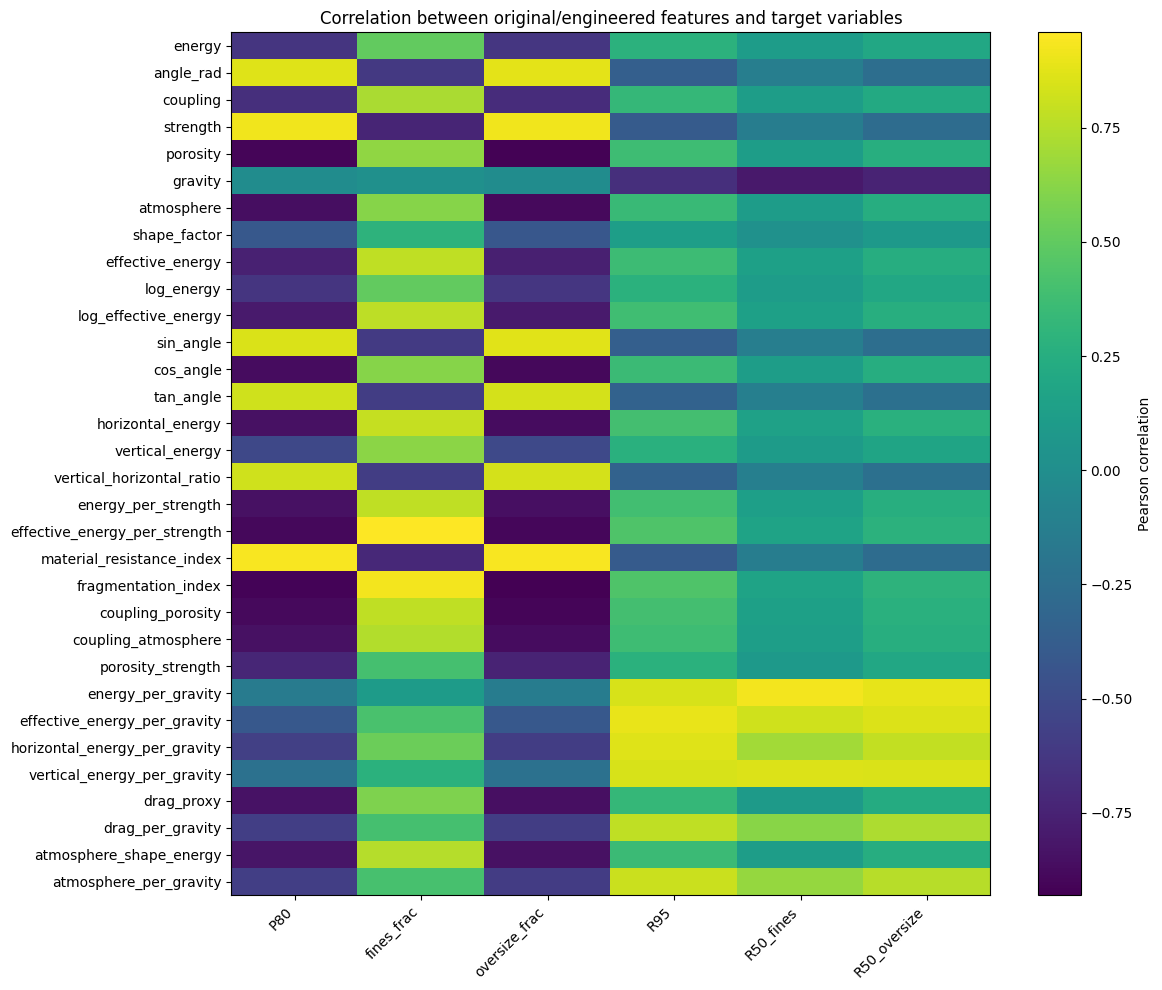

In [9]:
feature_target_corr = pd.concat([X_fe_train, labels], axis=1).corr().loc[all_feature_cols, target_cols]
display(feature_target_corr)

plt.figure(figsize=(12, 10))
plt.imshow(feature_target_corr, aspect="auto")
plt.colorbar(label="Pearson correlation")
plt.xticks(range(len(target_cols)), target_cols, rotation=45, ha="right")
plt.yticks(range(len(all_feature_cols)), all_feature_cols)
plt.title("Correlation between original/engineered features and target variables")
plt.tight_layout()
plt.show()

## 11. Top Correlated Features by Target

In [10]:
def top_correlations_for_target(corr_df: pd.DataFrame, target: str, top_n: int = 12) -> pd.DataFrame:
    out = corr_df[[target]].copy()
    out["abs_corr"] = out[target].abs()
    out["is_engineered"] = out.index.isin(engineered_cols)
    return out.sort_values("abs_corr", ascending=False).head(top_n)

for target in target_cols:
    print(f"\nTop correlations for target: {target}")
    display(top_correlations_for_target(feature_target_corr, target, top_n=12))


Top correlations for target: P80


,P80,abs_corr,is_engineered
material_resistance_index,0.937133,0.937133,True
strength,0.916946,0.916946,False
fragmentation_index,-0.914799,0.914799,True
porosity,-0.906075,0.906075,False
effective_energy_per_strength,-0.890036,0.890036,True
coupling_porosity,-0.882721,0.882721,True
cos_angle,-0.869420,0.869420,True
angle_rad,0.865685,0.865685,False
atmosphere,-0.861056,0.861056,False
sin_angle,0.855456,0.855456,True



Top correlations for target: fines_frac


,fines_frac,abs_corr,is_engineered
effective_energy_per_strength,0.959258,0.959258,True
fragmentation_index,0.929339,0.929339,True
horizontal_energy,0.795440,0.795440,True
energy_per_strength,0.776695,0.776695,True
coupling_porosity,0.775648,0.775648,True
effective_energy,0.775170,0.775170,True
log_effective_energy,0.774214,0.774214,True
atmosphere_shape_energy,0.746452,0.746452,True
coupling_atmosphere,0.742933,0.742933,True
strength,-0.732616,0.732616,False



Top correlations for target: oversize_frac


...

,R95,abs_corr,is_engineered
effective_energy_per_gravity,0.897452,0.897452,True
horizontal_energy_per_gravity,0.863967,0.863967,True
vertical_energy_per_gravity,0.847660,0.847660,True
energy_per_gravity,0.843934,0.843934,True
atmosphere_per_gravity,0.808981,0.808981,True
drag_per_gravity,0.774856,0.774856,True
gravity,-0.676681,0.676681,False
effective_energy_per_strength,0.439279,0.439279,True
fragmentation_index,0.438074,0.438074,True
horizontal_energy,0.397646,0.397646,True



Top correlations for target: R50_fines


,R50_fines,abs_corr,is_engineered
energy_per_gravity,0.923577,0.923577,True
vertical_energy_per_gravity,0.862833,0.862833,True
effective_energy_per_gravity,0.824431,0.824431,True
gravity,-0.803886,0.803886,False
horizontal_energy_per_gravity,0.699197,0.699197,True
atmosphere_per_gravity,0.659053,0.659053,True
drag_per_gravity,0.622230,0.622230,True
effective_energy_per_strength,0.166901,0.166901,True
fragmentation_index,0.162437,0.162437,True
horizontal_energy,0.148135,0.148135,True



Top correlations for target: R50_oversize


,R50_oversize,abs_corr,is_engineered
energy_per_gravity,0.891526,0.891526,True
effective_energy_per_gravity,0.861481,0.861481,True
vertical_energy_per_gravity,0.854484,0.854484,True
horizontal_energy_per_gravity,0.784218,0.784218,True
atmosphere_per_gravity,0.756944,0.756944,True
gravity,-0.744055,0.744055,False
drag_per_gravity,0.724746,0.724746,True
fragmentation_index,0.287604,0.287604,True
effective_energy_per_strength,0.286317,0.286317,True
horizontal_energy,0.268480,0.268480,True


### Interpretation Guide

If engineered features appear near the top, they likely capture useful physical structure. If only original features dominate, engineered features may still help nonlinear models but may not add strong linear information.

## 12. Mutual Information Analysis

Correlation detects mostly linear relationships. Mutual information can capture more general nonlinear dependencies.

In [11]:
mi_results = []

for target in target_cols:
    mi = mutual_info_regression(X_fe_train[all_feature_cols], labels[target], random_state=42)
    for feature, score in zip(all_feature_cols, mi):
        mi_results.append({
            "target": target,
            "feature": feature,
            "mi_score": score,
            "is_engineered": feature in engineered_cols,
        })

mi_df = pd.DataFrame(mi_results)

for target in target_cols:
    print(f"\nTop mutual information features for target: {target}")
    display(mi_df[mi_df["target"] == target].sort_values("mi_score", ascending=False).head(12))


Top mutual information features for target: P80


,target,feature,mi_score,is_engineered
18,P80,effective_energy_per_strength,1.594748,True
20,P80,fragmentation_index,1.219276,True
17,P80,energy_per_strength,0.968985,True
3,P80,strength,0.830598,False
14,P80,horizontal_energy,0.820608,True
30,P80,atmosphere_shape_energy,0.791180,True
19,P80,material_resistance_index,0.786684,True
21,P80,coupling_porosity,0.781143,True
22,P80,coupling_atmosphere,0.754178,True
10,P80,log_effective_energy,0.707268,True



Top mutual information features for target: fines_frac


,target,feature,mi_score,is_engineered
50,fines_frac,effective_energy_per_strength,1.882363,True
52,fines_frac,fragmentation_index,1.381677,True
49,fines_frac,energy_per_strength,0.909237,True
46,fines_frac,horizontal_energy,0.887705,True
40,fines_frac,effective_energy,0.824026,True
42,fines_frac,log_effective_energy,0.817578,True
53,fines_frac,coupling_porosity,0.811106,True
51,fines_frac,material_resistance_index,0.791738,True
54,fines_frac,coupling_atmosphere,0.772532,True
35,fines_frac,strength,0.769549,False



Top mutual information features for target: oversize_frac


...

,target,feature,mi_score,is_engineered
121,R95,effective_energy_per_gravity,1.125556,True
120,R95,energy_per_gravity,0.995657,True
122,R95,horizontal_energy_per_gravity,0.934598,True
123,R95,vertical_energy_per_gravity,0.928388,True
127,R95,atmosphere_per_gravity,0.875036,True
125,R95,drag_per_gravity,0.794207,True
101,R95,gravity,0.755970,False
114,R95,effective_energy_per_strength,0.409618,True
116,R95,fragmentation_index,0.343563,True
126,R95,atmosphere_shape_energy,0.245250,True



Top mutual information features for target: R50_fines


,target,feature,mi_score,is_engineered
152,R50_fines,energy_per_gravity,1.139681,True
133,R50_fines,gravity,1.047550,False
155,R50_fines,vertical_energy_per_gravity,0.910282,True
153,R50_fines,effective_energy_per_gravity,0.870689,True
159,R50_fines,atmosphere_per_gravity,0.759445,True
157,R50_fines,drag_per_gravity,0.702567,True
154,R50_fines,horizontal_energy_per_gravity,0.649345,True
148,R50_fines,fragmentation_index,0.162958,True
146,R50_fines,effective_energy_per_strength,0.148311,True
131,R50_fines,strength,0.116742,False



Top mutual information features for target: R50_oversize


,target,feature,mi_score,is_engineered
184,R50_oversize,energy_per_gravity,1.070012,True
185,R50_oversize,effective_energy_per_gravity,0.985292,True
187,R50_oversize,vertical_energy_per_gravity,0.944585,True
165,R50_oversize,gravity,0.923388,False
191,R50_oversize,atmosphere_per_gravity,0.848875,True
186,R50_oversize,horizontal_energy_per_gravity,0.787800,True
189,R50_oversize,drag_per_gravity,0.770263,True
178,R50_oversize,effective_energy_per_strength,0.302302,True
180,R50_oversize,fragmentation_index,0.248608,True
182,R50_oversize,coupling_atmosphere,0.227412,True


### Interpretation

Mutual information helps detect nonlinear relevance. A feature can have modest correlation but high mutual information if it separates regimes or interacts nonlinearly with the target.

## 13. Redundancy and Multicollinearity Check

In [12]:
feature_corr = X_fe_train[all_feature_cols].corr().abs()
threshold = 0.95
upper = feature_corr.where(np.triu(np.ones(feature_corr.shape), k=1).astype(bool))
high_corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "abs_corr"})
    .sort_values("abs_corr", ascending=False)
)
high_corr_pairs = high_corr_pairs[high_corr_pairs["abs_corr"] >= threshold]
print(f"Highly correlated feature pairs with abs(corr) >= {threshold}:")
display(high_corr_pairs)

Highly correlated feature pairs with abs(corr) >= 0.95:


,feature_1,feature_2,abs_corr
432,tan_angle,vertical_horizontal_ratio,1.000000
9,energy,log_energy,0.998242
44,angle_rad,cos_angle,0.997973
43,angle_rad,sin_angle,0.993869
266,effective_energy,log_effective_energy,0.989811
115,strength,material_resistance_index,0.985409
364,sin_angle,cos_angle,0.984911
596,effective_energy_per_strength,fragmentation_index,0.982737
959,drag_per_gravity,atmosphere_per_gravity,0.976213
400,cos_angle,vertical_horizontal_ratio,0.975926


### Interpretation

Highly correlated feature pairs are not automatically removed at this stage. For tree-based models, redundancy is usually acceptable in early experiments. For linear models or interpretability analysis, we may later remove or group redundant features.

## 14. PCA Visualization of Raw vs Engineered Features

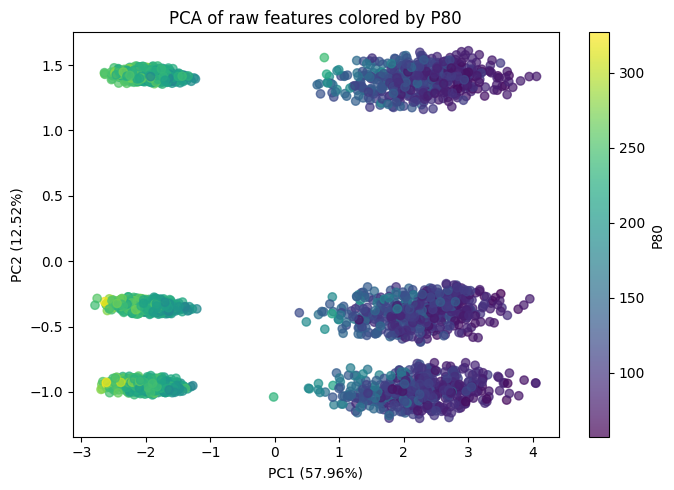

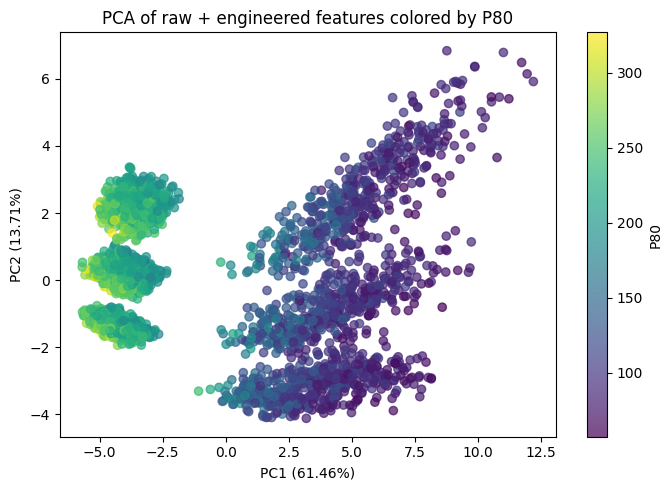

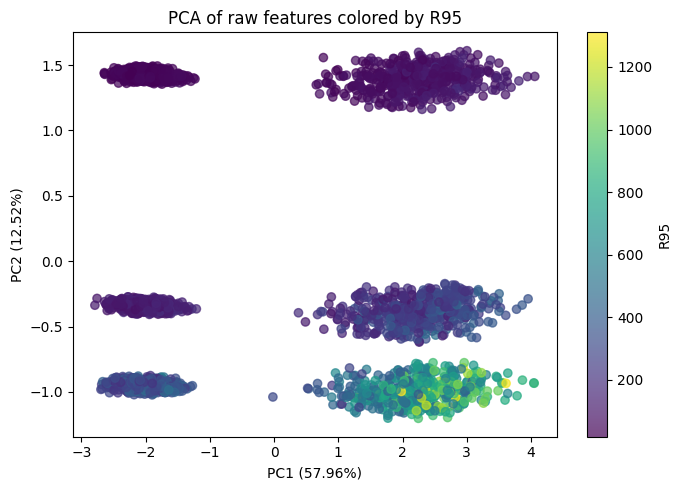

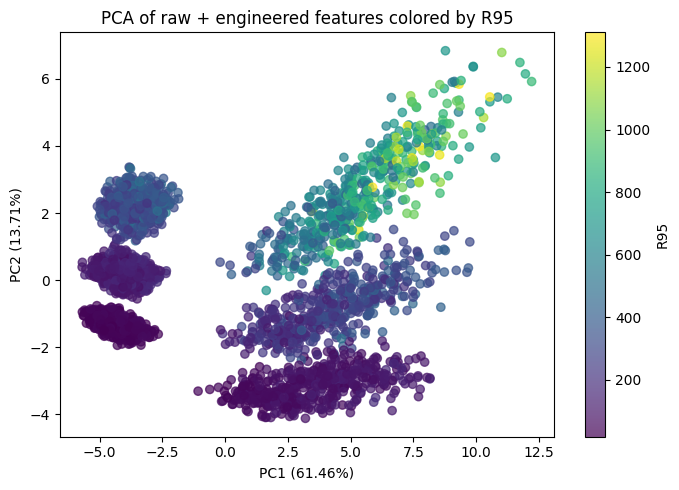

In [13]:
def plot_pca_projection(X: pd.DataFrame, color_values, title: str, color_label: str):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    pca = PCA(n_components=2, random_state=42)
    components = pca.fit_transform(X_scaled)

    plt.figure(figsize=(7, 5))
    scatter = plt.scatter(components[:, 0], components[:, 1], c=color_values, alpha=0.7)
    plt.colorbar(scatter, label=color_label)
    plt.title(title)
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%})")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%})")
    plt.tight_layout()
    plt.show()

plot_pca_projection(X_raw_train[input_cols], labels["P80"], "PCA of raw features colored by P80", "P80")
plot_pca_projection(X_fe_train[all_feature_cols], labels["P80"], "PCA of raw + engineered features colored by P80", "P80")
plot_pca_projection(X_raw_train[input_cols], labels["R95"], "PCA of raw features colored by R95", "R95")
plot_pca_projection(X_fe_train[all_feature_cols], labels["R95"], "PCA of raw + engineered features colored by R95", "R95")

## 15. Preliminary Feature Groups for Modeling

Based on physical reasoning and EDA results, we define several feature sets to compare in the next notebook. The final decision should be based on validation results, not only correlation or intuition.

In [14]:
raw_features = input_cols.copy()

core_physics_features = [
    "effective_energy", "sin_angle", "cos_angle",
    "horizontal_energy", "vertical_energy",
    "energy_per_strength", "effective_energy_per_strength",
    "energy_per_gravity", "effective_energy_per_gravity",
    "horizontal_energy_per_gravity", "vertical_energy_per_gravity",
    "drag_proxy", "drag_per_gravity",
    "material_resistance_index", "fragmentation_index",
]

fragmentation_features = raw_features + [
    "effective_energy", "sin_angle", "cos_angle",
    "energy_per_strength", "effective_energy_per_strength",
    "material_resistance_index", "fragmentation_index",
    "coupling_porosity", "coupling_atmosphere",
    "porosity_strength", "drag_proxy",
]

distance_features = raw_features + [
    "effective_energy", "sin_angle", "cos_angle",
    "horizontal_energy", "vertical_energy",
    "energy_per_gravity", "effective_energy_per_gravity",
    "horizontal_energy_per_gravity", "vertical_energy_per_gravity",
    "drag_proxy", "drag_per_gravity",
    "atmosphere_shape_energy", "atmosphere_per_gravity",
]

full_physics_features = raw_features + engineered_cols

feature_sets = {
    "raw_features": raw_features,
    "raw_plus_core_physics": raw_features + core_physics_features,
    "fragmentation_features": fragmentation_features,
    "distance_features": distance_features,
    "full_physics_features": full_physics_features,
}

for name, features in feature_sets.items():
    print(f"{name}: {len(features)} features")
    print(features)
    print()

raw_features: 8 features
['energy', 'angle_rad', 'coupling', 'strength', 'porosity', 'gravity', 'atmosphere', 'shape_factor']

raw_plus_core_physics: 23 features
['energy', 'angle_rad', 'coupling', 'strength', 'porosity', 'gravity', 'atmosphere', 'shape_factor', 'effective_energy', 'sin_angle', 'cos_angle', 'horizontal_energy', 'vertical_energy', 'energy_per_strength', 'effective_energy_per_strength', 'energy_per_gravity', 'effective_energy_per_gravity', 'horizontal_energy_per_gravity', 'vertical_energy_per_gravity', 'drag_proxy', 'drag_per_gravity', 'material_resistance_index', 'fragmentation_index']

fragmentation_features: 19 features
['energy', 'angle_rad', 'coupling', 'strength', 'porosity', 'gravity', 'atmosphere', 'shape_factor', 'effective_energy', 'sin_angle', 'cos_angle', 'energy_per_strength', 'effective_energy_per_strength', 'material_resistance_index', 'fragmentation_index', 'coupling_porosity', 'coupling_atmosphere', 'porosity_strength', 'drag_proxy']

distance_features: 

### Recommended Use in the Next Modeling Notebook

| Configuration | Feature set | Purpose |
|---|---|---|
| A | Raw features only | Baseline |
| B | Raw + core physics features | Main first candidate |
| C | Fragmentation features for `P80`, `fines_frac`, `oversize_frac` | Target-family-specific modeling |
| D | Distance features for `R95`, `R50_fines`, `R50_oversize` | Target-family-specific modeling |
| E | Full physics features | Check if extra engineered features improve validation |

A strong strategy is to train target-specific models:

- Fragmentation targets use `fragmentation_features`.
- Distance targets use `distance_features`.

## 16. Save Engineered Datasets and Feature Lists

In [15]:
X_fe_train.to_csv(PROCESSED_DIR / "X_train_engineered.csv", index=False)
X_fe_test.to_csv(PROCESSED_DIR / "X_test_engineered.csv", index=False)
labels.to_csv(PROCESSED_DIR / "y_train.csv", index=False)
feature_dictionary.to_csv(PROCESSED_DIR / "engineered_feature_dictionary.csv", index=False)

feature_sets_df = []
for set_name, features in feature_sets.items():
    for feature in features:
        feature_sets_df.append({"feature_set": set_name, "feature": feature})
feature_sets_df = pd.DataFrame(feature_sets_df)
feature_sets_df.to_csv(PROCESSED_DIR / "feature_sets.csv", index=False)

print("Saved files:")
print(PROCESSED_DIR / "X_train_engineered.csv")
print(PROCESSED_DIR / "X_test_engineered.csv")
print(PROCESSED_DIR / "y_train.csv")
print(PROCESSED_DIR / "engineered_feature_dictionary.csv")
print(PROCESSED_DIR / "feature_sets.csv")

Saved files:
/home/alouiyaz/projects/boom-challenge-ejecta-prediction/data/processed/X_train_engineered.csv
/home/alouiyaz/projects/boom-challenge-ejecta-prediction/data/processed/X_test_engineered.csv
/home/alouiyaz/projects/boom-challenge-ejecta-prediction/data/processed/y_train.csv
/home/alouiyaz/projects/boom-challenge-ejecta-prediction/data/processed/engineered_feature_dictionary.csv
/home/alouiyaz/projects/boom-challenge-ejecta-prediction/data/processed/feature_sets.csv


## 17. Feature Engineering Summary

### Main findings to verify after running this notebook

1. Engineered features should be checked for missing and infinite values.
2. Ratio features may amplify train-test distribution shift and must be monitored.
3. Correlation and mutual information help identify promising features, but final selection must be based on validation performance.
4. Fragmentation and distance targets should likely use different feature groups.
5. Gravity-based ratios are expected to be important for `R95`, `R50_fines`, and `R50_oversize`.
6. Strength, porosity, coupling, atmosphere, and angle-based features are expected to be important for `P80`, `fines_frac`, and `oversize_frac`.

### Modeling strategy for the next notebook

The next notebook should compare:

- raw features only,
- raw + core physics features,
- target-family-specific feature sets,
- full engineered feature set,
- optional log-transformed targets for skewed distance variables.

Recommended first models:

- `DummyRegressor` as a sanity baseline,
- `Ridge` with `StandardScaler`,
- `ExtraTreesRegressor`,
- `RandomForestRegressor`,
- `HistGradientBoostingRegressor`,
- later: `XGBoost`, `LightGBM`, and `CatBoost`.

Normalization is not required for tree-based models, but it is required for linear models, SVR, KNN, and neural networks.